In [1]:
import hoda
import tensorly as tl
import mne

!pip install line_profiler
%load_ext line_profiler

mne.set_log_level('ERROR')
tl.get_backend()


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[3],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,3,0,0
1,3,0,0
2,3,0,0
3,3,0,0
4,3,0,0
...,...,...,...
4195,3,0,0
4196,3,0,0
4197,3,0,0
4198,3,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 48)

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings

bttda = GreedyBTTDA(
    ranks=[None]*8,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        ortho=False,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42
       
    ),
    verbose=True,
    extra_train_info=False,
    
)
%env PYTHONWARNINGS=ignore
%lprun -f HODA.fit_backward bttda.fit(X,y)

env: PYTHONWARNINGS=ignore
Fitting block 1/8...


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 59.1416 s
File: /project/src/hoda/hoda.py
Function: fit_backward at line 152

Line #      Hits         Time  Per Hit   % Time  Line Contents
   152                                               def fit_backward(
   153                                                   self, X, y, X_centered=None, means=None, classes=None, class_counts=None
   154                                               ):
   155                                                   # TODO: calculate train info for initialization
   156                                                   # Convert to tensor
   157       168     955876.0   5689.7      0.0          if not tl.is_tensor(X):
   158                                                       X = tl.tensor(X)
   159       168     660536.0   3931.8      0.0          n_samples, *shape = X.shape
   160       168     214034.0   1274.0      0.0          order = len(shape)
   161                                           
   162           

In [6]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,train_score,val_score,train_scores,val_scores
0,1,2,0.905334,0.886720,"[[0.8603673469387755, 0.885734693877551, 0.882...","[[0.8603673469387755, 0.885734693877551, 0.882..."
1,2,1,0.905829,0.882098,"[[0.881, 0.8761224489795918, 0.874816326530612...","[[0.881, 0.8761224489795918, 0.874816326530612..."
2,3,2,0.910909,0.891853,"[[0.8960408163265304, 0.8937142857142857, 0.89...","[[0.8960408163265304, 0.8937142857142857, 0.89..."
3,4,2,0.915449,0.888078,"[[0.8929591836734695, 0.8869387755102041, 0.88...","[[0.8929591836734695, 0.8869387755102041, 0.88..."
4,5,1,0.917896,0.885753,"[[0.8836326530612245, 0.8867755102040817, 0.88...","[[0.8836326530612245, 0.8867755102040817, 0.88..."
5,6,1,0.918597,0.883786,"[[0.8820102040816327, 0.8815408163265306, 0.87...","[[0.8820102040816327, 0.8815408163265306, 0.87..."
6,7,1,0.918496,0.883512,"[[0.8816122448979592, 0.8796122448979592, 0.87...","[[0.8816122448979592, 0.8796122448979592, 0.87..."
7,8,1,0.919113,0.881378,"[[0.8786020408163264, 0.8767346938775511, 0.87...","[[0.8786020408163264, 0.8767346938775511, 0.87..."


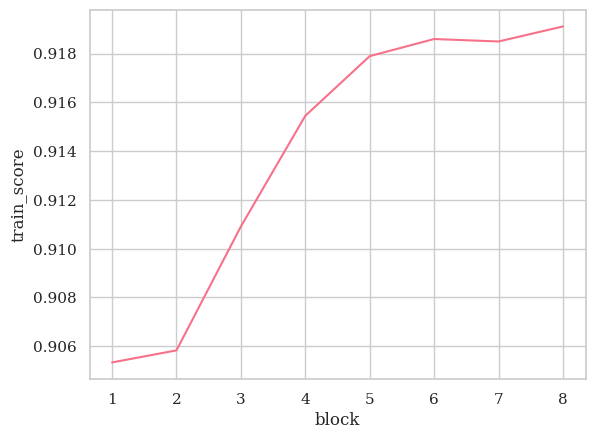

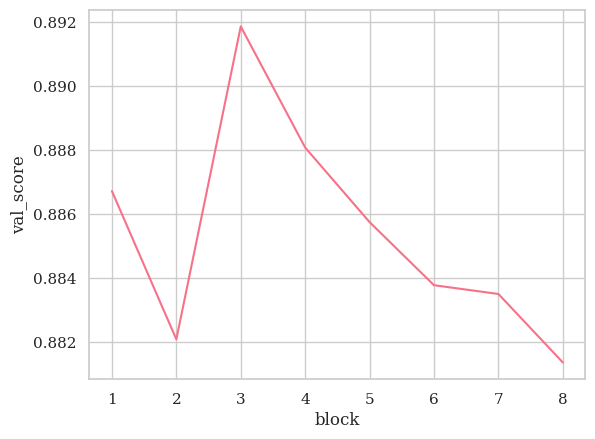

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

n_samples = X.shape[0]
sns.lineplot(data=df, x='block', y='train_score')
plt.show()
sns.lineplot(data=df, x='block', y='val_score')
#sns.lineplot(data=df, x='block', y='test_score')

plt.show()

In [8]:
Xt = bttda.transform(X)

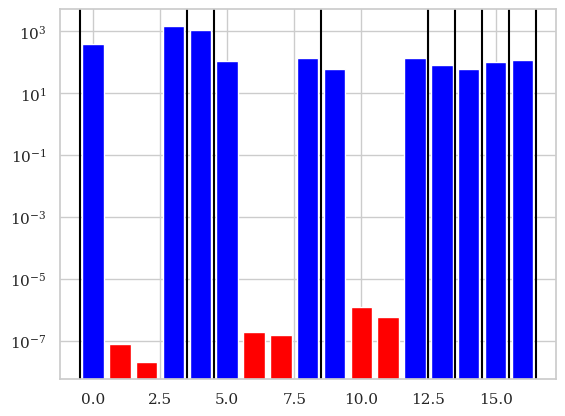

In [9]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

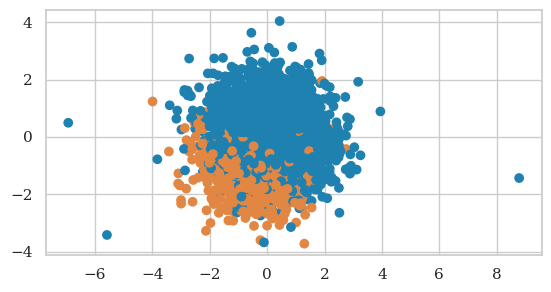

In [10]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [11]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]), units=dict(eeg=None))
joint_args=dict(ts_args=ts_args)

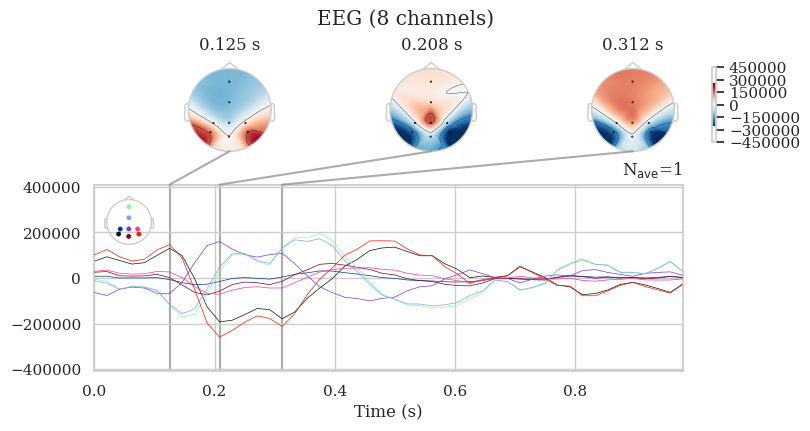

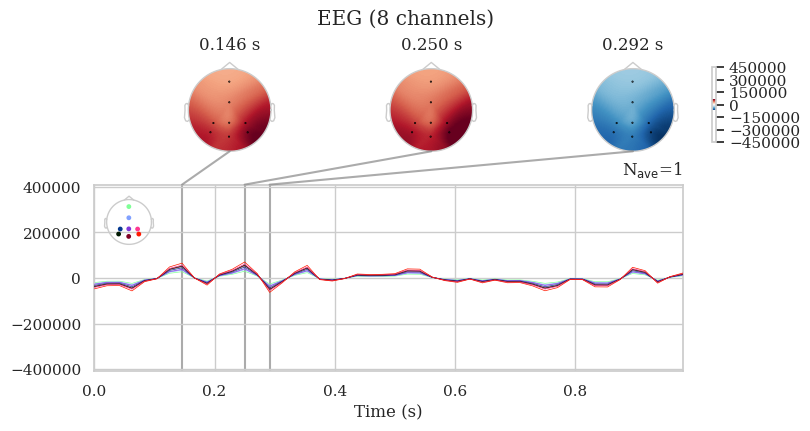

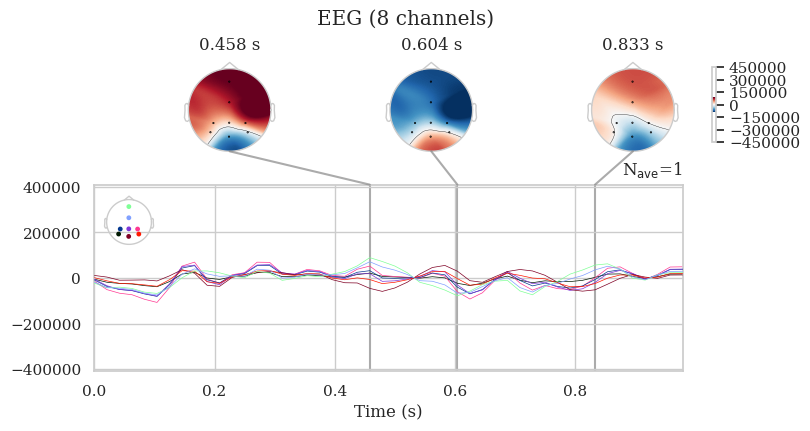

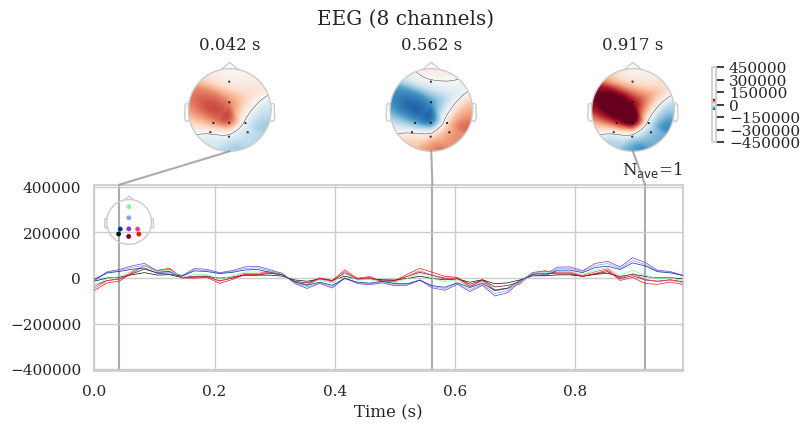

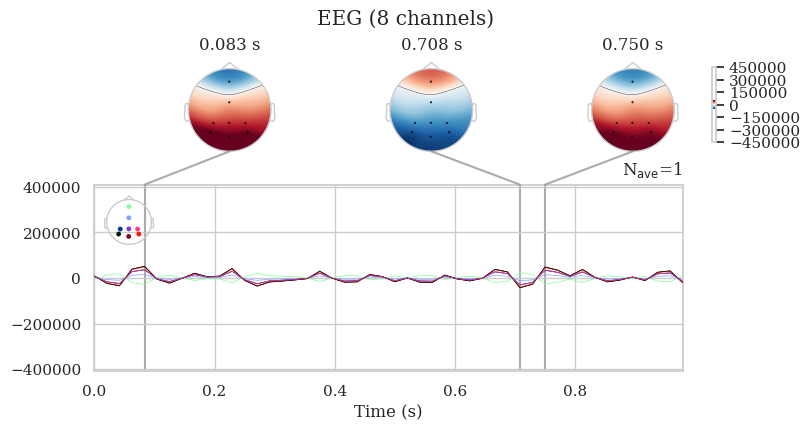

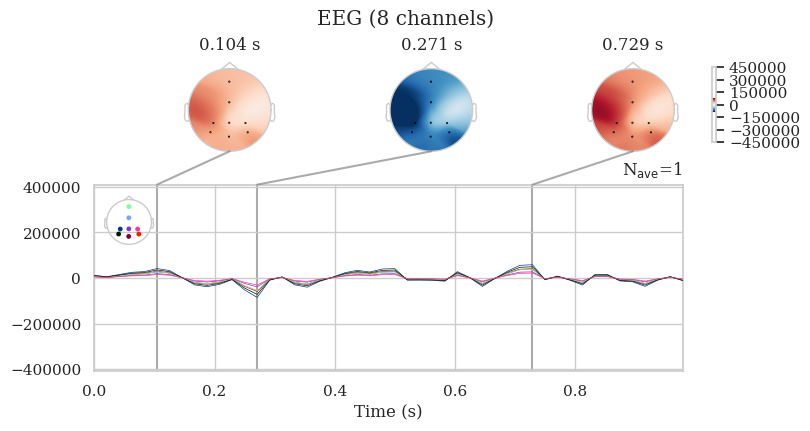

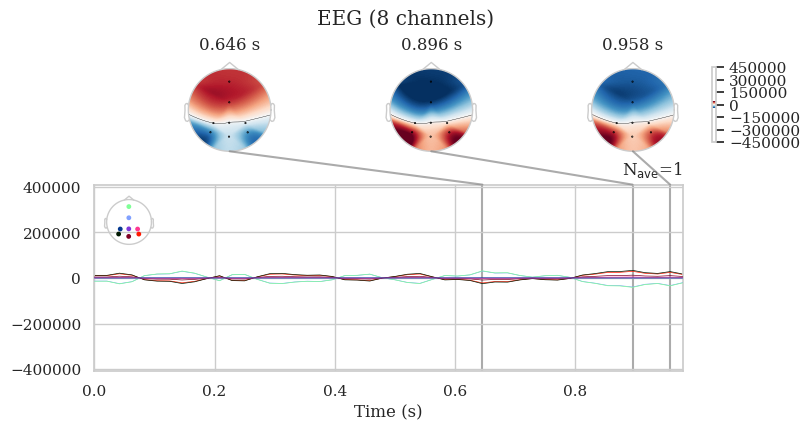

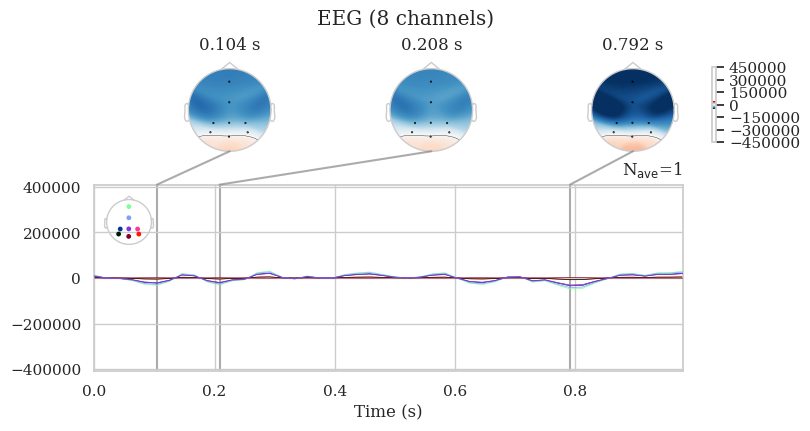

In [12]:
from mne import EvokedArray
for b in bttda.blocks_[:10]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [13]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

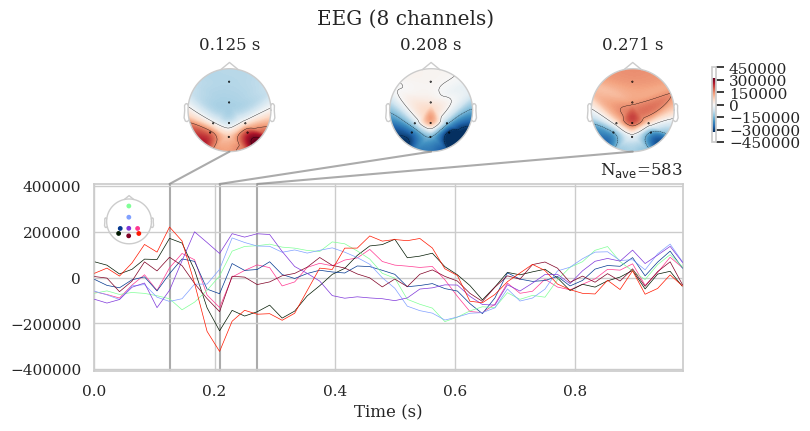

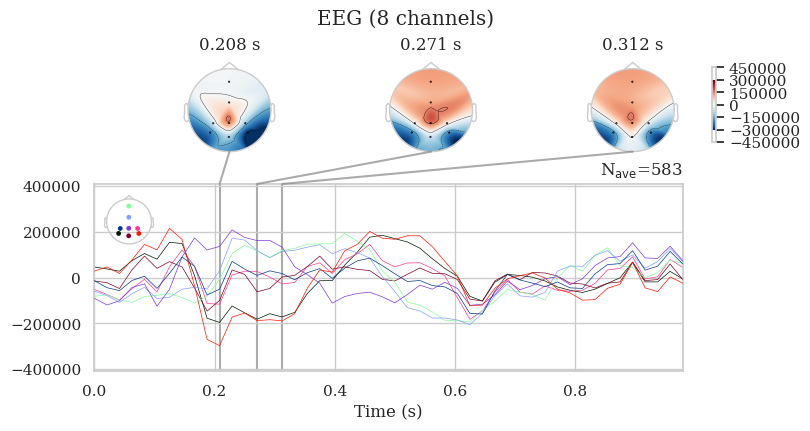

In [14]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


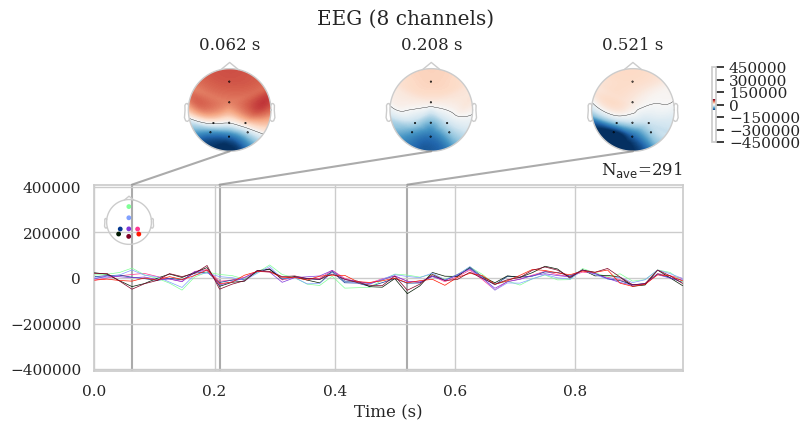

In [15]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)